In [83]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [84]:
import vmcnet.utils.io as io
import json
from ml_collections import ConfigDict

# _,d,all_p,_,_ = io.reload_vmc_state('.','soft_checkpoint.npz')
_,d,all_p,_,_ = io.reload_vmc_state('.','checkpoint.npz')

p = all_p['wf']
p_sg = all_p['sg']

# with open('soft_config.json', 'r') as f:
#   config = ConfigDict(json.load(f))


with open('config.json', 'r') as f:
  config = ConfigDict(json.load(f))

ion_pos = jnp.array(config.problem.ion_pos)
ion_charges = jnp.array(config.problem.ion_charges)
nelec = jnp.array(config.problem.nelec)

In [85]:
import vmcnet.models.construct as construct
slog_psi = construct.get_model_from_config(config.model, nelec, ion_pos, ion_charges)
log_psi_apply = construct.slog_psi_to_log_psi_apply(slog_psi.apply)

In [86]:
surrogate_config = config.surrogate
spin_split = construct.get_spin_split(nelec)

compute_input_streams = construct.get_compute_input_streams_from_config(
    surrogate_config.input_streams, ion_pos
)

backflow = construct.get_backflow_from_config(
    surrogate_config.backflow,
    spin_split,
)

from vmcnet.models.construct import FermiNetSurrogate

surrogate = FermiNetSurrogate(
    spin_split, compute_input_streams, backflow
)

sg_apply = surrogate.apply

In [87]:
import vmcnet.physics.potential as potential
ei_term = potential.create_electron_ion_coulomb_potential(ion_pos, ion_charges, nparticles=1)
ee_term = potential.create_electron_electron_coulomb_potential(nparticles=1)

In [88]:
import vmcnet.physics.random_particle as random_particle
kinetic_term = random_particle.create_random_particle_kinetic_energy(log_psi_apply, nparticles=1)

In [89]:
def SPLE_apply(params, pos, perm):
    perm = jnp.array(perm)
    perm_pos = pos[..., perm, :]
    result = ei_term(params, perm_pos)
    result += ee_term(params, perm_pos)
    result += kinetic_term(params, pos, perm)
    return result

SPLE_apply = jax.jit(jax.vmap(SPLE_apply, in_axes=(None, 0, None), out_axes=0))

In [90]:
import vmcnet.physics.kinetic as kinetic
import vmcnet.physics.core as phys_core

kinetic_fn = kinetic.create_laplacian_kinetic_energy(log_psi_apply)
ei_potential_fn = potential.create_electron_ion_coulomb_potential(
    ion_pos, ion_charges
)
ee_potential_fn = potential.create_electron_electron_coulomb_potential()
ii_potential_fn = potential.create_ion_ion_coulomb_potential(
    ion_pos, ion_charges
)
FLE_apply = phys_core.combine_local_energy_terms(
    [kinetic_fn, ei_potential_fn, ee_potential_fn, ii_potential_fn]
)

FLE_apply = jax.jit(jax.vmap(FLE_apply, in_axes=(None, 0, None), out_axes=0))

In [91]:
###### RUN LINEAR TESTS ######

In [116]:
step = 0.01
offset = step / 2
leftX = -2.5
rightX = 2.5

grid_pos = jnp.arange(leftX - offset, rightX + 2*offset,step)
ngrid = grid_pos.shape[0]

x_1_pos = jnp.expand_dims(grid_pos,-1)
y_1_pos = jnp.zeros((ngrid,1))
z_1_pos = jnp.zeros((ngrid,1))
pos_1 = jnp.concatenate([x_1_pos, y_1_pos, z_1_pos], axis=-1)

npos = ngrid

# pos_2 = jnp.expand_dims(jnp.array([0.5,0.0,0.]), 0)
pos_2 = jnp.expand_dims(jnp.array([0.8,0.0,0.]), 0)

pos_2 = jnp.repeat(pos_2, npos, axis=0)

# pos_3 = jnp.expand_dims(jnp.array([-1.5,0.5,0.]), 0
pos_3 = jnp.expand_dims(jnp.array([-0.8,0.0,0.]), 0)

pos_3 = jnp.repeat(pos_3, npos, axis=0)
pos = jnp.stack([pos_1,pos_2,pos_3], axis=1)


In [117]:
s,l = jax.jit(slog_psi.apply)(p, pos)
psi = s * jnp.exp(l)

def log_abs_psi(Params, pos):
    return slog_psi.apply(Params, pos)[1]

grad_log_psi_apply = jax.grad(log_abs_psi, argnums=1)

def grad_log_psi_norm_apply(p, pos):
    grad_log_psi = grad_log_psi_apply(p,pos)
    return jnp.sqrt(jnp.sum(jnp.square(grad_log_psi)))

grad_log_psi_norm_apply = jax.vmap(grad_log_psi_norm_apply, in_axes=(None, 0), out_axes=0)
    
grad_log_psi_norm = grad_log_psi_norm_apply(p, pos)


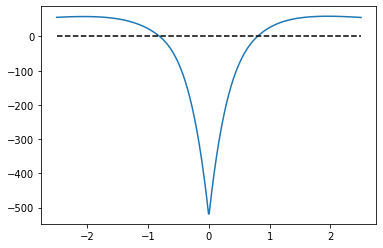

In [118]:
plt.plot(x_1_pos, psi)
plt.plot(x_1_pos, jnp.zeros_like(x_1_pos), color='black', linestyle='--')

In [119]:
FLE = FLE_apply(p, pos, None)

ii_potential_fn = potential.create_ion_ion_coulomb_potential(
    ion_pos, ion_charges
)

SPLE_1 = SPLE_apply(p,pos, [0,1,2])
SPLE_2 = SPLE_apply(p,pos, [1,2,0])
SPLE_3 = SPLE_apply(p,pos, [2,1,0])

FLE_from_SPLE = (SPLE_1+SPLE_2+SPLE_3)/3 + ii_potential_fn(p, pos)

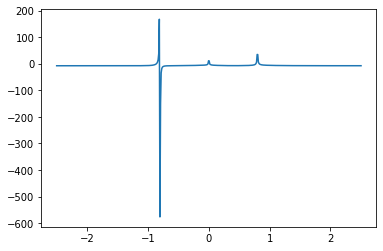

In [120]:
plt.plot(x_1_pos, FLE)

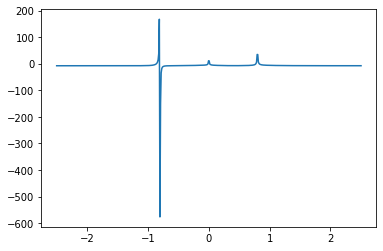

In [121]:
plt.plot(x_1_pos, FLE_from_SPLE)

In [122]:
sg_predic = sg_apply(p_sg, pos)

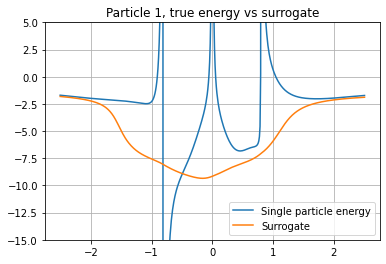

In [132]:
fig, ax = plt.subplots()

ax.set_title("Particle 1, true energy vs surrogate")
ax.plot(x_1_pos, SPLE_1, label='Single particle energy')
ax.plot(x_1_pos, sg_predic[...,0], label='Surrogate')

ax.legend()
ax.set_ylim([-15,5])
ax.grid()

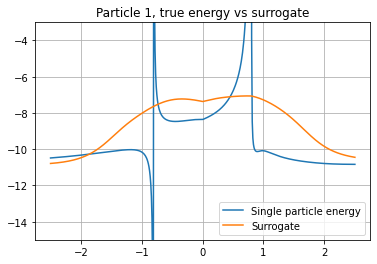

In [135]:
fig, ax = plt.subplots()

ax.set_title("Particle 1, true energy vs surrogate")
ax.plot(x_1_pos, SPLE_2, label='Single particle energy')
ax.plot(x_1_pos, sg_predic[...,1], label='Surrogate')

ax.legend()
ax.set_ylim([-15,-3])

ax.grid()

(-15.0, 5.0)

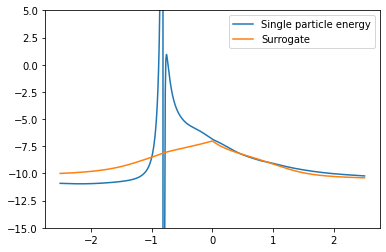

In [141]:
fig, ax = plt.subplots()

ax.plot(x_1_pos, SPLE_3, label='Single particle energy')
ax.plot(x_1_pos, sg_predic[...,2], label='Surrogate')
ax.legend()
ax.set_ylim([-15,5])

In [143]:
# SCRATCH AFTER THIS!!!!

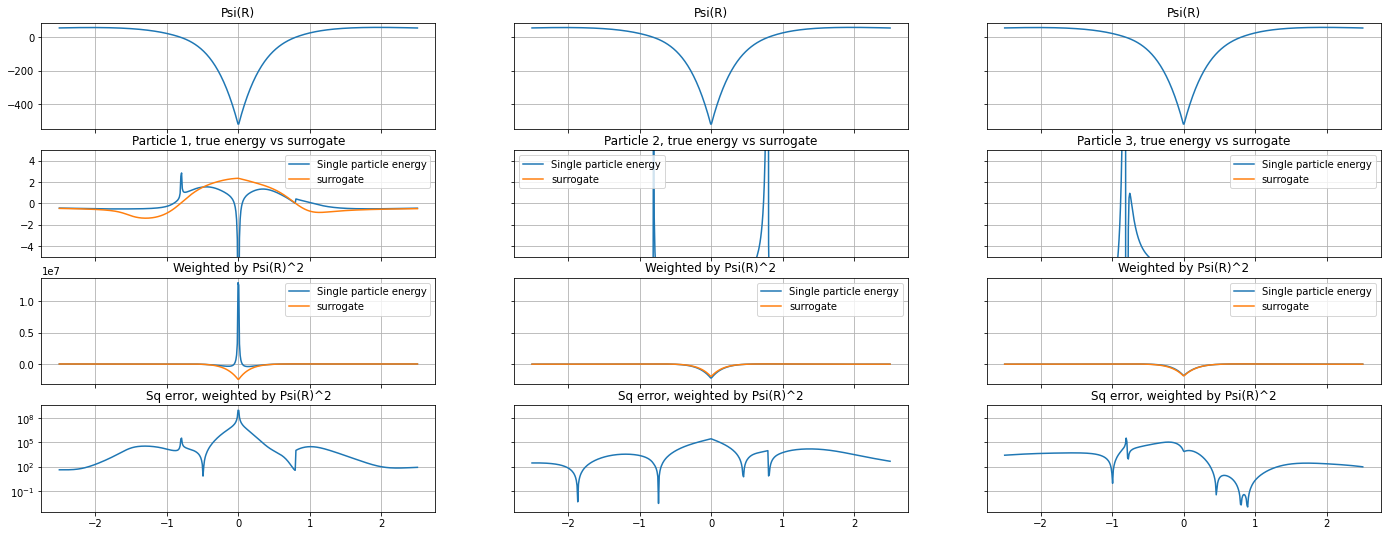

In [142]:
fig, axs = plt.subplots(nrows=4, ncols=3, sharex=True, sharey='row', figsize=(24,9))

ax = [a[0] for a in axs]
ax[0].plot(x_1_pos, psi)
ax[0].grid()
ax[0].set_title("Psi(R)")

ax[1].set_title("Particle 1, true energy vs surrogate")
ax[1].plot(x_1_pos, SPLE_1 / grad_log_psi_norm * s, label='Single particle energy')
ax[1].plot(x_1_pos, sg_predic[...,0]/ grad_log_psi_norm * s, label='surrogate')
ax[1].legend()
ax[1].set_ylim([-5,5])
ax[1].grid()


ax[2].set_title("Weighted by Psi(R)^2")
ax[2].plot(x_1_pos, SPLE_1 * psi**2, label='Single particle energy')
ax[2].plot(x_1_pos, sg_predic[...,0] * psi**2, label='surrogate')
ax[2].legend()
ax[2].grid()


ax[3].set_title("Sq error, weighted by Psi(R)^2")
ax[3].plot(x_1_pos, (SPLE_1 -  sg_predic[...,0])**2 * psi**2, label='Single particle energy')
ax[3].set_yscale('log')
ax[3].grid()

ax = [a[1] for a in axs]
ax[0].plot(x_1_pos, psi)
ax[0].grid()
ax[0].set_title("Psi(R)")

ax[1].set_title("Particle 2, true energy vs surrogate")
ax[1].plot(x_1_pos, SPLE_2, label='Single particle energy')
ax[1].plot(x_1_pos, sg_predic[...,1], label='surrogate')
ax[1].legend()
# ax[1].set_ylim([-20,10])
ax[1].grid()


ax[2].set_title("Weighted by Psi(R)^2")
ax[2].plot(x_1_pos, SPLE_2 * psi**2, label='Single particle energy')
ax[2].plot(x_1_pos, sg_predic[...,1] * psi**2, label='surrogate')
ax[2].legend()
ax[2].grid()


ax[3].set_title("Sq error, weighted by Psi(R)^2")
ax[3].plot(x_1_pos, (SPLE_2 -  sg_predic[...,1])**2 * psi**2, label='Single particle energy')
ax[3].set_yscale('log')
ax[3].grid()

ax = [a[2] for a in axs]
ax[0].plot(x_1_pos, psi)
ax[0].grid()
ax[0].set_title("Psi(R)")

ax[1].set_title("Particle 3, true energy vs surrogate")
ax[1].plot(x_1_pos, SPLE_3, label='Single particle energy')
ax[1].plot(x_1_pos, sg_predic[...,2], label='surrogate')
ax[1].legend()
# ax[1].set_ylim([-20,10])
ax[1].grid()

ax[2].set_title("Weighted by Psi(R)^2")
ax[2].plot(x_1_pos, SPLE_3 * psi**2, label='Single particle energy')
ax[2].plot(x_1_pos, sg_predic[...,2] * psi**2, label='surrogate')
ax[2].legend()
ax[2].grid()

ax[3].set_title("Sq error, weighted by Psi(R)^2")
ax[3].plot(x_1_pos, (SPLE_3 -  sg_predic[...,2])**2 * psi**2, label='Single particle energy')
ax[3].set_yscale('log')
ax[3].grid()


In [150]:
##### 2D ANALYSIS #####

In [43]:
step = 0.1
offset = step / 2
leftX = 0
rightX = 2.5

grid_pos = jnp.arange(leftX - offset, rightX + 2*offset,step)
ngrid = grid_pos.shape[0]

x_1_pos = jnp.expand_dims(jnp.repeat(grid_pos, ngrid),-1)
y_1_pos = jnp.expand_dims(jnp.tile(grid_pos, ngrid), -1)
npos = ngrid**2

z_1_pos = jnp.zeros((npos,1))
pos_1 = jnp.concatenate([x_1_pos, y_1_pos, z_1_pos], axis=-1)

In [44]:
pos_2 = jnp.expand_dims(jnp.array([1.5,0.,0.]), 0)
pos_2 = jnp.repeat(pos_2, npos, axis=0)

pos_3 = jnp.expand_dims(jnp.array([-0.5,0.,0.]), 0)
pos_3 = jnp.repeat(pos_3, npos, axis=0)

In [45]:
pos = jnp.stack([pos_1,pos_2,pos_3], axis=1)

In [46]:
s,l = slog_psi.apply(p, pos)
psi = s * jnp.exp(l)

In [47]:
FLE = FLE_apply(p, pos, None)

In [48]:
ii_potential_fn = potential.create_ion_ion_coulomb_potential(
    ion_pos, ion_charges
)

SPLE_1 = SPLE_apply(p,pos, [0,1,2])
SPLE_2 = SPLE_apply(p,pos, [1,2,0])
SPLE_3 = SPLE_apply(p,pos, [2,1,0])

FLE_from_SPLE = (SPLE_1+SPLE_2+SPLE_3)/3 + ii_potential_fn(p, pos)

In [49]:
s,l = slog_psi.apply(p, pos)
psi = s * jnp.exp(l)

def log_abs_psi(Params, pos):
    return slog_psi.apply(Params, pos)[1]

grad_log_psi_apply = jax.grad(log_abs_psi, argnums=1)

def grad_log_psi_norm_apply(p, pos):
    grad_log_psi = grad_log_psi_apply(p,pos)
    return jnp.sqrt(jnp.sum(jnp.square(grad_log_psi)))

grad_log_psi_norm_apply = jax.vmap(grad_log_psi_norm_apply, in_axes=(None, 0), out_axes=0)
    
grad_log_psi_norm = grad_log_psi_norm_apply(p, pos)

In [50]:
sg_predic = sg_apply(p_sg, pos)

Text(0.5, 0, 'Y')

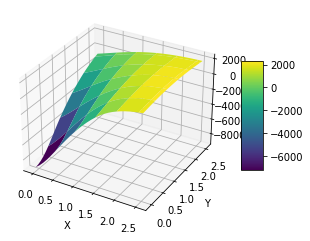

In [51]:
from matplotlib import cm

fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape(psi, (ngrid, ngrid))

surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none"
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")

Text(0.5, 0, 'Y')

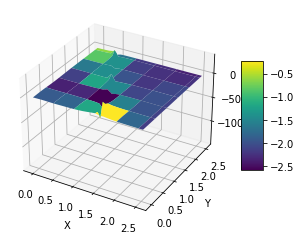

In [54]:
fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape(FLE, (ngrid, ngrid))

surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none"
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")


Text(0.5, 0, 'Y')

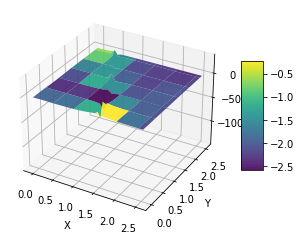

In [55]:
fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape(FLE_from_SPLE, (ngrid, ngrid))


surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none", alpha=0.9
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")


Text(0.5, 0, 'Y')

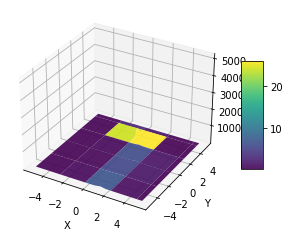

In [103]:
fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape((sg_predic[...,0] - SPLE_1)**2, (ngrid, ngrid))
# Z = jnp.where(np.abs(Z)>10, np.mean(Z), Z)


surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none", alpha=0.9
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")

Text(0.5, 0, 'Y')

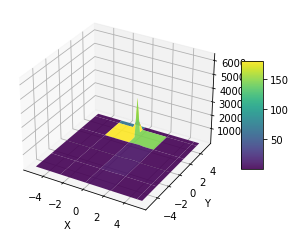

In [104]:
fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape((sg_predic[...,1] - SPLE_2)**2, (ngrid, ngrid))


surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none", alpha=0.9
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")

Text(0.5, 0, 'Y')

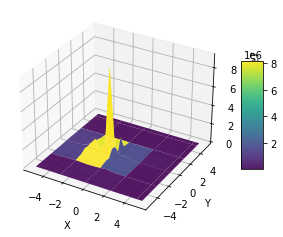

In [105]:
fig,ax=plt.subplots(subplot_kw={"projection": "3d"})

Y,X = np.meshgrid(grid_pos, grid_pos)
Z = jnp.reshape((sg_predic[...,2] - SPLE_3)**2 * psi**2, (ngrid, ngrid))

surf = ax.plot_surface(
    X, Y, Z, rstride=5, cstride=5, cmap="viridis", edgecolor="none", alpha=0.9
)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("X")
ax.set_ylabel("Y")